# 02 — Four-model comparison
Reproduce the reference paper's experimental logic for sequential distributions: RNN, BRNN, CA-RNN, and CA-BRNN. Here CA models use projected-PIT calibration; sequential regularization is isolated later.

In [1]:
import sys
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import CARNNConfig, TrainingConfig
from innovcal.data import simulate_multivariate_series
from innovcal.experiments import run_four_model_comparison
OUT = ROOT / 'results' / 'four_model'
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
values = simulate_multivariate_series(1200, regime='nonlinear', seed=2027)
training = TrainingConfig(epochs=150, batch_size=64, patience=20, seed=2027, bayesian_samples=2)
result = run_four_model_comparison(values, model_config=CARNNConfig(4, hidden_dim=32), training_config=training, lambda_cal=10.0, lambda_seq=0.0)
display(result.metrics.sort_values('pit_calibration_error'))
result.metrics.to_csv(OUT / 'metrics.csv', index=False)
for name, history in result.histories.items(): history.to_csv(OUT / f'{name.lower()}_history.csv', index=False)

,model,best_epoch,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
1,BRNN,30,5.368500,0.947009,1.250190,0.907955,3.259481,3.982974,0.000464,0.069246,0.050729,0.000471,0.066654,0.055877
3,CA-BRNN,30,5.369446,0.946991,1.250140,0.907955,3.250496,3.982373,0.000521,0.068733,0.049861,0.000534,0.065945,0.056070
2,CA-RNN,19,5.243908,0.931886,1.228299,0.911364,3.168315,3.826116,0.001017,0.070359,0.064284,0.001091,0.069367,0.068973
0,RNN,19,5.243533,0.931878,1.228243,0.913636,3.163264,3.825163,0.001060,0.070992,0.064062,0.001098,0.069546,0.068973


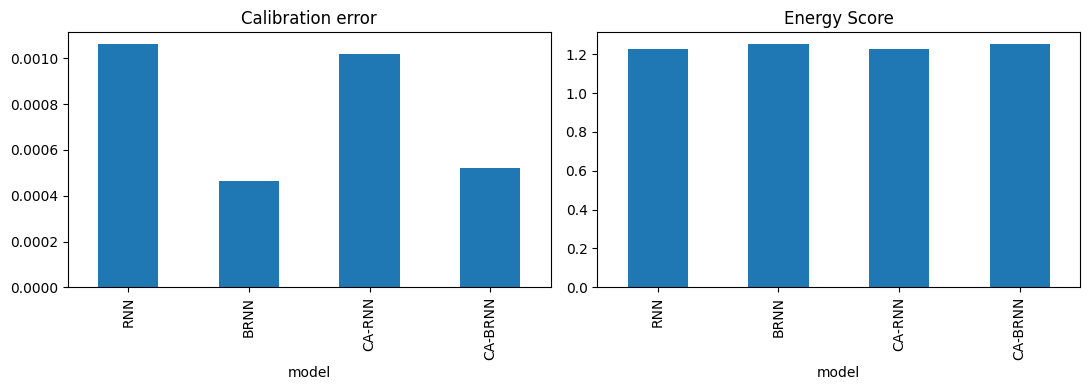

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
result.metrics.plot.bar(x='model', y='pit_calibration_error', ax=axes[0], legend=False, title='Calibration error')
result.metrics.plot.bar(x='model', y='energy_score', ax=axes[1], legend=False, title='Energy Score')
plt.tight_layout()